## Disciplina: Estudos Especiais 1

# Simulação Suspensão ativa

O sistema consiste de duas massas, cada uma apoiada por uma mola e um amortecedor. A massa suspensa, $M_{S}$, representa a massa do corpo do veículo enquanto a massa não suspensa, $M_{us}$, representa o pneu no modelo quarter-car. Este é um sistema de quarta ordem pois há quatro variáveis dependentes, as duas massas e as duas molas. A mola $K_{s}$ e o amortecedor $B_{s}$ suportam o peso do corpo sobre o pneu. A mola $K_{us}$ e o amortecedor $B_{us}$ modelam a rigidez do pneu em contato com a estrada. O sistema também conta com um controlador LQR para simular a força compensadora do sistema de suspensão ativa. No entanto, não abordaremos a parte que envolve o controle do sistema nesse trabalho.

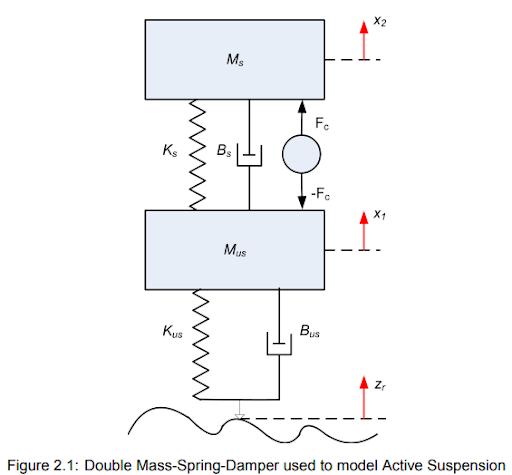

Observe o comportamento do sistema através dos dados coletados no laboratório do CTAI

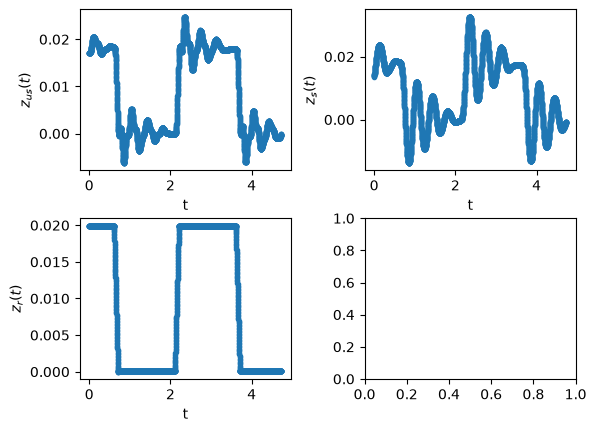

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

sheet_url="https://docs.google.com/spreadsheets/d/1ns8HIf9hgXXLDuzDEGPYwXsyomjN11aO01H7uM1d3BQ/edit#gid=0"
url_1=sheet_url.replace('/edit#gid=', '/export?format=csv&gid=')

#Fiz uma atualização para já criar automaticamente as listas
arquivo=pd.read_csv(url_1,decimal=',')
arquivo.head()

t = np.array(arquivo['t'])
#vr = np.array(arquivo['Vr'])
zr = np.array(arquivo['Zr'])
zs = np.array(arquivo['X2'])
zus = np.array(arquivo['X1'])
vr = np.gradient(zr, t)

# Gráficos
# Criando a figura com quatro subplot
fig, axs = plt.subplots(2, 2)
# Plotando os gráficos em cada um dos subplot
axs[0, 0].plot(t, zus,'.')
axs[0, 0].set_xlabel('t')
axs[0, 0].set_ylabel(r'$z_{us}(t)$')

axs[0, 1].plot(t, zs,'.')
axs[0, 1].set_xlabel('t')
axs[0, 1].set_ylabel(r'$z_{s}(t)$')

axs[1, 0].plot(t, zr,'.')
axs[1, 0].set_xlabel('t')
axs[1, 0].set_ylabel(r'$z_{r}(t)$')




# Ajustando o espaço entre os subplot
plt.subplots_adjust(wspace=0.35, hspace=0.3)

# Mostrando o gráfico
plt.show()


## Modelagem

Para a modelagem matemática do sistema, foi utilizado o diagrama de corpo livre. Nesse sistema, são consideradas como entradas o comando de controle da suspensão ativa $F_{c}$ e a posição da superfície da estrada $z_{r}$ . As coordenadas $x_{1}$ e $x_{2}$ representam o deslocamento do pneu e da carroceria em relação ao solo. A direção positiva é para cima.


Para achar as equações de movimento do sistema, foi utilizado o diagrama de corpo livre em cada massa para determinar todas as forças que agem sobre elas. Todas as condições iniciais são consideradas zero. No diagrama da massa $M_{s}$ , vemos que as forças que agem sobre ela são a força elástica, a força de amortecimento, a força da suspensão ativa e a gravidade.

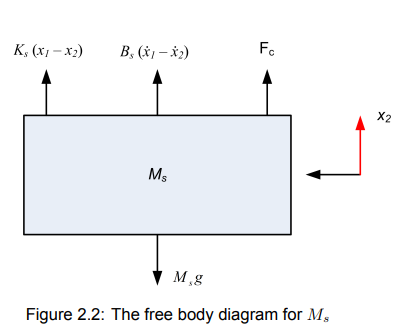

Segue então a equação de movimento de $M_{s}$ :

$$\ddot{x_{2}} = -g + \frac{F_{c}}{M_{s}} + \frac{B_{s}\dot{x_{1}}}{M_{s}} -  \frac{B_{s}\dot{x_{2}}}{M_{s}} + \frac{K_{s}x_{1}}{M_{s}} - \frac{K_{s}x_{2}}{M_{s}} $$

No caso de $M_{us}$ , as forças que atuam sobre a massa são as forças elásticas, a força de amortecimento, a força da suspensão ativa e a da gravidade.

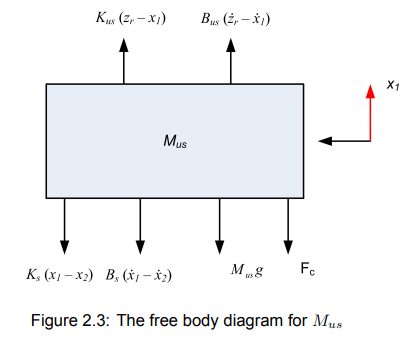

A equação de movimento de $M_{us}$ será então:


$$ \ddot{x_{1}} = -g - \frac{F_{c}}{M_{us}} - \frac{(B_{s}+B_{us})\dot{x_{1}}}{M_{us}} + \frac{B_{s}\dot{x_{2}}}{M_{us}} + \frac{B_{us}\dot{z_{r}}}{M_{us}} - \frac{(K_{us}+K_{s})x_{1}}{M_{us}} + \frac{K_{s}x_{2}}{M_{us}} + \frac{z_{r}K_{us}}{M_{us}} $$



## Eliminando a gravidade da equação

É possível provar matematicamente que a força da gravidade altera apenas os pontos de equilíbrio das equações de movimento da suspensão ativa e não afeta as dinâmicas do sistema. Nos pontos de equilíbrio, $x_{1} = x_{eq1}$ , $x_{2} = x_{eq2}$ , todas as derivadas de $x_{1}$ e $x_{2}$ são de ordem zero. Além disso, a superfície da estrada $z_{r}$ e suas derivadas bem como a força de controle $F_{c}$ são zero. Substituindo essas mudanças nas equações anteriores temos os seguintes resultados:

$$K_{s}x_{eq1} - K_{s}x_{eq2} + M_{us}g + x_{eq1}K_{us} = 0 $$

$$M_{s}g + K_{s}x_{eq2}-K_{s}x_{eq2} = 0 $$

Como resultado, os pontos de equilíbrio devido a gravidade vão ser:

$$x_{eq1} = -\frac{g(M_{s}+M_{us})}{K_{us}} $$

$$ x_{eq1} = -\frac{g(M_{s}K_{us} + M_{us}K_{s} + K_{s}M_{us})}{K_{us}K_{s}}$$

Para remover a gravidade das equações de movimento, aplicamos as seguintes mudanças de variáveis:

$$x_{1} = z_{us} - \frac{g(M_{s} + M_{us})}{K_{us}} $$

$$x_{2} = z_{s} - \frac{M_{s}g}{K_{s}} - \frac{g(M_{s} + M_{us})}{K_{us}} $$

$$\dot{x_{1}} = \dot{z_{us}} $$

$$\dot{x_{2}} = \dot{z_{s}} $$

$$\ddot{x_{1}} = \ddot{z_{us}} $$

$$\ddot{x_{2}} = \ddot{z_{s}} $$

Substituindo a mudança de variáveis nas equações de movimento da suspensão ativa temos as seguintes equações onde a gravidade foi eliminada das equações. Nesse caso, a posição relaxada das molas, ou seja, zus = 0, zs = 0, será o ponto de equilíbrio do sistema.

$$M_{us}\ddot{z_{us}} = -B_{s}\dot{z_{us}}  -B_{us}\dot{z_{us}} -  F_{c} + B_{s}\dot{z_{s}} + B_{us}\dot{z_{r}} - (z_{us} - z_{s})K_{s} - (z_{us} - z_{r})K_{us} $$
$$M_{s}\ddot{z_{s}} = B_{s}\dot{z_{us}} + F_{c} - B_{s}\dot{z_{s}} - (z_{s} - z_{us})K_{s}  $$

As únicas entradas do sistema são a força de controle e a superfície da estrada.

Como não vamos utilizar o sistema de controle podemos dizer que $F_c=0$

$$M_{us}\ddot{z_{us}} = -B_{s}\dot{z_{us}}  -B_{us}\dot{z_{us}} + B_{s}\dot{z_{s}} + B_{us}\dot{z_{r}} - (z_{us} - z_{s})K_{s} - (z_{us} - z_{r})K_{us} $$
$$M_{s}\ddot{z_{s}} = B_{s}\dot{z_{us}}- B_{s}\dot{z_{s}} - (z_{s} - z_{us})K_{s}  $$

Arrumando
\begin{align}
M_{us}\ddot{z_{us}} &= -(B_{s} + B_{us})\dot{z_{us}} + B_{s}\dot{z_{s}} -(K_{s}+K_{us})z_{us}  + K_{s}z_{s}  + K_{us}z_{r} + B_{us}\dot{z_{r}}\\
M_{s}\ddot{z_{s}} &= B_{s}\dot{z_{us}} - B_{s}\dot{z_{s}} - K_{s}z_{s} + K_{s}z_{us}
\end{align}

Para resolver o sistema anterior numericamente, precisaremos aplicar a redução de ordem, para tanto vamos aplicar as seguintes mudanças de variáveis:
\begin{align}
\dot{z_{us}} = v_{us}\\
\dot{v_{us}} = \ddot{z_{us}}\\
\dot{z_{s}} = v_{s}\\
\dot{v_{s}} = \ddot{z_{s}}\\
\dot{z_{r}} = v_{r}\\
\end{align}

Então substituindo no sistema de edo anterior, teremos
\begin{align}
\dot{z_{us}} &= v_{us}\\
\dot{v_{us}} &= \frac{1}{M_{us}}\left(-(K_{s}+K_{us})z_{us} -(B_{s} + B_{us})v_{us} + K_{s}z_{s} + B_{s}v_{s} + K_{us}z_{r} + B_{us}v_{r}\right)\\
\dot{z_{s}} &= v_{s}\\
\dot{v_{s}} &= \frac{1}{M_s}\left(K_{s}z_{us}+B_{s}v_{us} - K_{s}z_{s} - B_{s}v_s\right)\\
\end{align}

Como se trata de um sistema linear podemos colocar na forma matricial
\begin{align}
\underset{\dot{\mathbf{X}}(t)}{\underbrace{\begin{bmatrix}
\dot{z_{us}}(t)\\
\dot{v_{us}}(t)\\
\dot{z_{s}}(t)\\
\dot{v_{s}}(t)\\
\end{bmatrix}}}&=
\underset{\mathbf{A}}{\underbrace{\begin{bmatrix}
0 & 1 & 0 & 0\\
-\frac{K_s+K_{us}}{M_{us}} & -\frac{B_s+B_{us}}{M_{us}} & \frac{K_s}{M_{us}} & \frac{B_s}{M_{us}}\\
0 & 0 & 0 & 1\\
\frac{K_s}{M_{s}} & \frac{B_s}{M_{s}} & -\frac{K_s}{M_s} & -\frac{B_s}{M_s}
\end{bmatrix}}}\cdot
\underset{\mathbf{X}(t)}{\underbrace{\begin{bmatrix}
z_{us}(t)\\
v_{us}(t)\\
z_{s}(t)\\
v_{s}(t)\\
\end{bmatrix}}}+
\underset{\mathbf{B}}{\underbrace{\begin{bmatrix}
0 & 0\\
\frac{K_{us}}{M_{us}} & \frac{B_{us}}{M_{us}}\\
0 & 0\\
0& 0
\end{bmatrix}}}\cdot
\underset{\mathbf{U}(t)}{\underbrace{\begin{bmatrix}
z_{r}(t)\\
v_{r}(t)\\
\end{bmatrix}}}\\
\mathbf{\dot{X}}(t) &= \mathbf{A}\cdot\mathbf{X}(t) + \mathbf{B}\cdot\mathbf{U}(t)
\end{align}






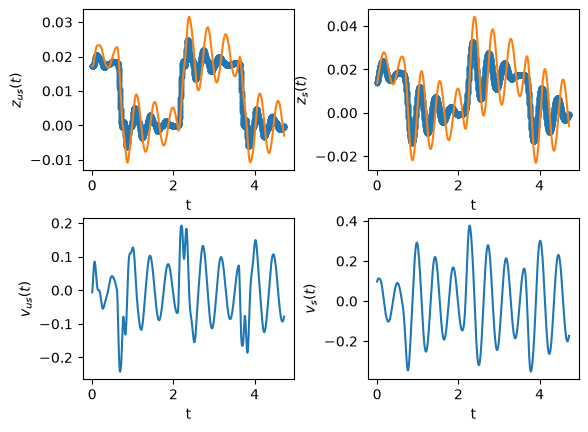

In [4]:
#@title Construindo o sistema de EDO
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
# Função contendo as EDOs
def active_suspension(t,X,U,params):
  Ms = 2.45
  Mus = 1
  Ks, Kus, Bs, Bus = params
  A = np.array([[0,1,0,0],
                [-(Ks+Kus)/Mus, -(Bs+Bus)/Mus, Ks/Mus, Bs/Mus],
                [0,0,0,1],
                [Ks/Ms, Bs/Ms, -Ks/Ms, -Bs/Ms]])

  B = np.array([[0,0],
                [Kus/Mus,Bus/Mus],
                [0,0],
                [0,0]])

  dXdt = A.dot(X) + B.dot(U)
  return dXdt

# Parametros desconhecidos do sistema fornecidos pelo manual do fabricante (estimetiva inicial)
Ks = 900
Kus = 1250
Bs = 7.5
Bus = 5
params0 = [Ks,Kus,Bs,Bus]

# Simulando a EDO para uma dada condição inicial e entrada conhecida
# teste da funçao para os dados experimentais
n_exp = len(t)            # Numero de valores medidos
dt = t[1]-t[0]            # Intervalo de amostragem dos dados
U_exp = np.array([zr, vr])  # Valores experimentais das entradas externas
Y_exp = np.array([zus,zs]) # Valores experimentais das saidas medidas
# Alocando as variáveis em matrizes
X = np.zeros((4,n_exp))   # X = [zus,vus,zs,vs]
# Condição inicial baseada no experimento
#x[:,0] todas as linhas na posição 1 da coluna
X[:,0] = np.array([zus[0], # Primeiro valor medido de zus
                   (-3*zus[0]+4*zus[1]-1*zus[2])/(2*dt), # vus(0) calculada pela forma da derivada progressiva aplicada ao primeiro ponto de zus
                   zs[0], # Primeiro valor medido de zs
                   (-3*zs[0]+4*zs[1]-1*zs[2])/(2*dt)] # vs calculada pela forma da derivada progressiva aplicada ao primeiro ponto de zus
                  )
tn = np.zeros_like(t) # Vetor para guarda o tempo do solve
for k in range(n_exp-1):
  sol = solve_ivp(active_suspension,
                  [t[k],t[k+1]],
                  X[:,k],
                  args=(U_exp[:,k],params0))
  tn[k+1] = sol.t[-1]
  X[:,k+1] = sol.y[:,-1]


zus_n = X[0,:]
vus_n = X[1,:]
zs_n = X[2,:]
vs_n = X[3,:]


# Gráficos
# Criando a figura com quatro subplot
fig, axs = plt.subplots(2, 2)
# Plotando os gráficos em cada um dos subplot
axs[0, 0].plot(t, zus,'.',tn,zus_n)
axs[0, 0].set_xlabel('t')
axs[0, 0].set_ylabel(r'$z_{us}(t)$')

axs[0, 1].plot(t, zs,'.',tn,zs_n)
axs[0, 1].set_xlabel('t')
axs[0, 1].set_ylabel(r'$z_{s}(t)$')

axs[1, 0].plot(t, vus_n)
axs[1, 0].set_xlabel('t')
axs[1, 0].set_ylabel(r'$v_{us}(t)$')

axs[1, 1].plot(t, vs_n)
axs[1, 1].set_xlabel('t')
axs[1, 1].set_ylabel(r'$v_{s}(t)$')

# Ajustando o espaço entre os subplot
plt.subplots_adjust(wspace=0.35, hspace=0.3)

# Mostrando o gráfico
plt.show()

In [5]:
print(t[1])
print(t[0])
X[:,0]

0.001
0.0


array([ 0.01719055, -0.0062635 ,  0.01364683,  0.097408  ])

# Questões

Com base no gráfico anterior, percebermos que o modelo com os parâmetros fornecido pelo fabricante posssui um erro quando comparado aos dados observados no protótipo.

1.   Assumindo que as massas são parâmetros fixos, avalie quais dos parâmetros restante tem maior impacto sobre a função objetivo minimos quadrados.
2.   Estime os parâmetros desconhecidos para que o modelo se aproxime melhor dos dados experimentais. \\
  2.1. Utilize 3 métodos de otimização diferente, em seguida compare e discuta os resultados, levando em consideração valor da função objetivo, valores encontrados para os parâmetros, comportamento do modelo e sensibilidade com relação a estimativa inicial.    




In [6]:
#@title  Confecção do modelo

def modelo(param, t, Y_exp, U_exp):
#U_exp é um array das entradas internas experimentais zr, vr
#Y_exp é um array das saídas experimentais zs, zus
  amostras = len(t) #quantidade de dados medidos, que dá cerca de 237, visto que fatiamos os dados colocando amostras de 20 em 20 posições de um total de 4727
  intervalo = t[1] - t[0] #intervalo de tempo, que equivale a dt na expressão original
  zus = Y_exp[0]
  zs = Y_exp[1]
  X = np.zeros((4, len(t))) #Cria uma matriz de 0 de dimensão (4, 237), isto é, 4 linhas e 237 colunas, sendo a linha 0 referente zus
  #a linha 1 referente a vus, a linha 2 refenrete a zs e a linha 3, a vs

  #Montando o sistemas de derivadas que passará no solve para integração
  X[:, 0] = np.array([zus[0], # Primeiro valor medido de zus
                   (-3*zus[0]+4*zus[1]-1*zus[2])/(2*dt), # vus(0) calculada pela forma da derivada progressiva aplicada ao primeiro ponto de zus
                   zs[0], # Primeiro valor medido de zs
                   (-3*zs[0]+4*zs[1]-1*zs[2])/(2*dt)] # vs calculada pela forma da derivada progressiva aplicada ao primeiro ponto de zus
                  )
  tn = np.zeros_like(t) #Vetor cheio de zeros que guarda e tem a mesma dimensão de t de tempo
  for b in range(n_exp-1):
    #O solve vai resolver o sistema de EDOs recebido. Sabe-se, de acordo com o conteúdo visto em aula, que o primeiro parâmetro
    # é o modelo; o segundo, o intervalo de tempo, o terceiro, as variáveis entrada e saída e o quarto, os parâmetros externos
      sol = solve_ivp(active_suspension,
                  [t[b],t[b+1]],
                  X[:,b],
                  args=(U_exp[:,b],param))
      tn[b + 1] = sol.t[-1] #Salva em tn o último tempo da solução da solve_ivp para o elemento, ou seja, o tempo final
      X[:, b+1] = sol.y[:,-1] #Salva a obtenção das variáveis no último instante de tempo

  return X




In [7]:
#@title Executando o modelo
  #Agora que passamos as soluções para X, vamos passar os valores de cada cada linha para cada variável simulada respectiva para facilitar
  #o calculo do erro das saídas
X_simulado = modelo(params0, t, Y_exp, U_exp)
print(X_simulado)
zus_simulado = X_simulado[0, :] #Passa o resultado da linha 0 e de todas as colunas para zus
vus_simulado = X_simulado[1, :]
zs_simulado = X_simulado[2, :]
vs_simulado = X_simulado[3, :]

[[ 0.01719055  0.01718483  0.01718028 ... -0.0028125  -0.00289208
  -0.00297097]
 [-0.0062635  -0.00514886 -0.00394204 ... -0.07990588 -0.07923654
  -0.07855231]
 [ 0.01364683  0.01374472  0.01384356 ... -0.00569746 -0.00587305
  -0.00604725]
 [ 0.097408    0.09837357  0.09930177 ... -0.17627123 -0.17489986
  -0.17349554]]


In [8]:
#@title Confecção da função objetivo, isto é, o cálculo do erro (soma do somatório das diferenças quadráticas)

#Com o modelo bem executado, toma-se os valores obtidos e passados por X_simulado para os calculos
def fob(param, t, Y_exp, U_exp):

    x_sim = modelo(param, t, Y_exp, U_exp)
    erro_total = sum((x_sim[0,:] - zus)**2 + (x_sim[2,:] - zs)**2)
    return erro_total


erro_fob = fob(params0, t, Y_exp, U_exp)

param1 = [4.5, 7 , 9 ,12]
erro2 = fob(param1, t ,Y_exp, U_exp)
param2 = [1 ,2,3,4]

erro3 = fob(param2, t, Y_exp,U_exp)

#Teste da fob com parâmetros diferentes a fim de validar os seus resultados
print(erro_fob)
print(erro2)
print(erro3)

#Como a fob apresentou o erro corretamente, agora vale-se utilizar outras estruturas para se alcaçar o objetivo da otimização com base nos
#parâmetros (definidos em params0) e as variáveis do sistemas





0.6536426406022866
2.6317212990884697
24.94067131977324


In [9]:
#@title Sensibilidade do modelo em relação aos parâmetros fornecidos pela fabricante

#Criação de um vetor que varia em torno do valor inicial a fim de testar a corretude dele

#Como os parâmetros definidos em params0 são, em ordem e com valores iniciais, Ks (900), Kus (1250), Bs (7.5), Bus (5)
#params0 = [Ks,Kus,Bs,Bus]

#KS
KS = np.linspace(100, 2200, 100) #Cria um vetor composto por 150 valores que variam de 100 a 2200
KSfob = np.zeros_like(KS) #Cria um vetor de zeros do tamanho de KS para eu armazenar o resultado da fob específica
for i in range(len(KS)): #Percorre o vetor para armazenar a fob com somente o parâmetro KS alterado a fim de descobrir o impacto dele para a fob.
  KSfob[i] = fob([KS[i], Kus, Bs, Bus],t, Y_exp, U_exp)

#KUS

KUS = np.linspace(200, 1500, 150)
KUSfob = np.zeros_like(KUS)
for i in range(len(KUS)):
  KUSfob[i] =  fob([Ks, KUS[i], Bs, Bus], t, Y_exp, U_exp)



#BS
BS = np.linspace(2, 15, 15)
BSfob = np.zeros_like(BS)
for i in range(len(BS)):
  BSfob[i] = fob([Ks, Kus, BS[i], Bus],t, Y_exp, U_exp)


#BUS

BUS = np.linspace(1, 10, 15)
BUSfob = np.zeros_like(BUS)
for i in range(len(BUS)):
  BUSfob[i] = fob([Ks, Kus, Bs, BUS[i]], t, Y_exp, U_exp)



Text(0, 0.5, '$B_{us}fob$')

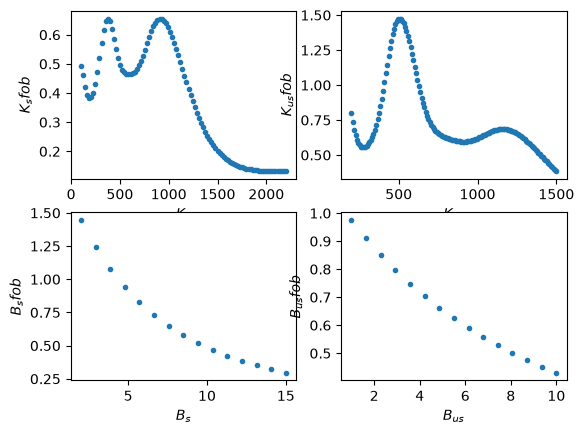

In [10]:
#@title Exibição gráfica do impacto da alteração dos parâmetros isoladamente.
#Gráfico de KS
GraficoParams, axs = plt.subplots(2, 2)
axs[0, 0].plot(KS, KSfob,'.')
axs[0, 0].set_xlabel('$K_{s}$')
axs[0, 0].set_ylabel(r'$K_{s}fob$')

axs[0, 1].plot(KUS, KUSfob, '.')
axs[0, 1].set_xlabel("$K_{us}$")
axs[0, 1].set_ylabel("$K_{us}fob$")


axs[1, 0].plot(BS, BSfob, '.')
axs[1, 0].set_xlabel('$B_{s}$')
axs[1, 0].set_ylabel('$B_{s}fob$')

axs[1, 1].plot(BUS, BUSfob, '.')
axs[1, 1].set_xlabel('$B_{us}$')
axs[1, 1].set_ylabel('$B_{us}fob$')





# **Discussão da Parte 1**
A fim de verificar o impacto que cada parâmetro proporciona à função objetivo dele, tomou-se como base o pior cenário da alteração de cada parâmetro.
Percebeu-se que, no caso de Ks (900 como valor padrão), com uma variação de 1000 unidades, a função objetivo reduziu o seu valor em aproximadamente 0.7 unidade, o que significa uma variação de 0,0007.
No caso de Kus, ao alterar o seu valor em aproximadamente 700 unidades, houve uma variação de cerca de 0,85, o q que significa que a variação total foi de 0,0012.
No caso de Bs, verificou se que uma variação de 5 unidades em torno do seu valor original resultou em uma variação de aproximadamente 0,85 na sua função objetivo. Isso resultou uma variação total de 0,17.
No caso de Bus, ao alterar 5 unidades em torno do seu valor original, o valor da sua função objetivo modificou-se em 0,5 unidade. Isso resultou em uma variação total de 0,1.
Nesse sentido, ao analisar graficamente, foi possível inferir que as maiores variações na função objetivo estão bem localizadas nos parâmetros referentes ao amortecedor. Isso significa que tais parâmetros são mais relevantes na redução dos erros do modelo em relação ao fenômeno real, que é representado pelos dados experimentais.

In [11]:
#@title Otimizando a função objetivo com o método padrão
from scipy.optimize import minimize

params_iniciais = [900, 1250, 7.5, 5]
resultado = minimize(fob,params_iniciais, args= ( t, Y_exp, U_exp))
print(resultado)
param_otim = resultado.x

X_simulado = modelo(param_otim, t, Y_exp, U_exp)
print(X_simulado)
zus2_simulado = X_simulado[0, :]
vus2_simulado = X_simulado[1, :]
zs2_simulado = X_simulado[2, :]
vs2_simulado = X_simulado[3, :]



  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 0.02898588224975395
        x: [ 8.665e+02  2.053e+03  2.480e+00  7.394e+01]
      nit: 113
      jac: [-2.016e-07  1.739e-07 -3.669e-06  4.787e-07]
 hess_inv: [[ 2.679e+06 -4.868e+06  7.708e+04 -1.046e+06]
            [-4.868e+06  7.077e+07  6.493e+05 -1.058e+06]
            [ 7.708e+04  6.493e+05  1.602e+04 -8.258e+04]
            [-1.046e+06 -1.058e+06 -8.258e+04  6.582e+05]]
     nfev: 640
     njev: 128
[[ 1.71905460e-02  1.71859145e-02  1.71844500e-02 ... -6.47841199e-04
  -6.33409880e-04 -6.18851264e-04]
 [-6.26350000e-03 -3.02381299e-03  7.08599297e-05 ...  1.43663020e-02
   1.44956526e-02  1.46208935e-02]
 [ 1.36468300e-02  1.37448065e-02  1.38438973e-02 ... -1.04644812e-03
  -9.91411497e-04 -9.36289330e-04]
 [ 9.74080000e-02  9.85392872e-02  9.96367276e-02 ...  5.49890818e-02
   5.50817810e-02  5.51601681e-02]]


In [12]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
# Plotando os gráficos em cada um dos subplot

fig = make_subplots(rows=2, cols=2)

# Gráfico para zus
trace1_zus = go.Scatter(x=t, y=zus, mode='markers', name='Dados Experimentais')
trace2_zus = go.Scatter(x=tn, y=zus2_simulado, mode='lines', name='Modelo Otimizado')
fig.add_trace(trace1_zus, row=1, col=1)
fig.add_trace(trace2_zus, row=1, col=1)
fig.update_xaxes(title_text='t', row=1, col=1)
fig.update_yaxes(title_text='$z_{us}(t)$', row=1, col=1)

# Gráfico para zs
trace1_zs = go.Scatter(x=t, y=zs, mode='markers', name='Dados Experimentais')
trace2_zs = go.Scatter(x=tn, y=zs2_simulado, mode='lines', name='Modelo Otimizado')
fig.add_trace(trace1_zs, row=1, col=2)
fig.add_trace(trace2_zs, row=1, col=2)
fig.update_xaxes(title_text='t', row=1, col=2)
fig.update_yaxes(title_text='$z_{s}(t)$', row=1, col=2)

# Gráfico para vus
trace1_vus = go.Scatter(x=t, y=vus2_simulado, mode='markers', name='Dados Experimentais')
fig.add_trace(trace1_vus, row=2, col=1)
fig.update_xaxes(title_text='t', row=2, col=1)
fig.update_yaxes(title_text='$v_{us}(t)$', row=2, col=1)

# Gráfico para vs
trace1_vs = go.Scatter(x=t, y=vs2_simulado, mode='markers', name='Dados Experimentais')
fig.add_trace(trace1_vs, row=2, col=2)
fig.update_xaxes(title_text='t', row=2, col=2)
fig.update_yaxes(title_text='$v_{s}(t)$', row=2, col=2)

fig.update_layout(
    title='Gráficos de Comparação: Dados Experimentais vs. Modelo Otimizado',
    template='plotly_white'
)
fig.show()


In [13]:
#@title Otimizando por meio de outros métodos

import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import minimize

params_in = [900, 1250, 7.5, 5]

#Estes três métodos funcionam muito bem.

resultadoBFGS = minimize(fob,params_in, args= (t, Y_exp, U_exp), method = "BFGS")




In [14]:
print(resultadoBFGS)

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 0.02898588224975395
        x: [ 8.665e+02  2.053e+03  2.480e+00  7.394e+01]
      nit: 113
      jac: [-2.016e-07  1.739e-07 -3.669e-06  4.787e-07]
 hess_inv: [[ 2.679e+06 -4.868e+06  7.708e+04 -1.046e+06]
            [-4.868e+06  7.077e+07  6.493e+05 -1.058e+06]
            [ 7.708e+04  6.493e+05  1.602e+04 -8.258e+04]
            [-1.046e+06 -1.058e+06 -8.258e+04  6.582e+05]]
     nfev: 640
     njev: 128


In [15]:

resultadoPowell =  minimize(fob,params_in, args= (t, Y_exp, U_exp), method = "Powell")
print(resultadoPowell)

 message: Optimization terminated successfully.
 success: True
  status: 0
     fun: 0.041700086585034164
       x: [ 6.063e+02  3.680e+05  7.093e+00  1.721e+05]
     nit: 3
   direc: [[ 1.000e+00  0.000e+00  0.000e+00  0.000e+00]
           [ 0.000e+00  1.000e+00  0.000e+00  0.000e+00]
           [ 0.000e+00  0.000e+00  1.000e+00  0.000e+00]
           [ 0.000e+00  0.000e+00  0.000e+00  1.000e+00]]
    nfev: 172


In [20]:
limites = [(0.0001, None)] * len(params_in) 

# 2. Roda o minimize passando o argumento bounds=limites
resultadoLBFGS = minimize(fob, params_in, args=(t, Y_exp, U_exp), method="L-BFGS-B", bounds=limites)

print(resultadoLBFGS)

  message: CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
  success: True
   status: 0
      fun: 0.028983635553618672
        x: [ 8.700e+02  2.039e+03  2.451e+00  7.294e+01]
      nit: 45
      jac: [-3.879e-07  7.841e-08 -9.180e-06 -1.476e-06]
     nfev: 250
     njev: 50
 hess_inv: <4x4 LbfgsInvHessProduct with dtype=float64>


# **Discussão da Parte 2**

A fim de chegar à solução da segunda questão, foram utilizados três métodos de otimização além da chamada padrão da função: BFGS, Powell e L-BFGS-B. É importante ressaltar que, considerando a alta densidade de dados experimentais, tais métodos demandaram um elevado custo computacional para serem executados propriamente. Abaixo, apresenta-se a discussão acerca do comportamento de cada um deles. Ressalta-se que todos apresentaram alterações nos parâmetros em relação à estimativa inicial, demonstrando a importância do processo de otimização.

**Método BFGS**

Para esse método, obtiveram-se os seguintes valores otimizados para os parâmetros: 8.665e+02, 2.053e+03, 2.480e+00 e 7.394e+01. O valor do erro (função objetivo) convergiu para 0.02898. Esses valores foram exatamente os mesmos obtidos ao utilizar a função minimize sem qualquer especificação de método. Isso ocorre porque o algoritmo BFGS (ou suas variações quase-Newton) é a escolha padrão adotada internamente pela biblioteca SciPy para problemas não restritos, confirmando a consistência do resultado.

**Método Powell**

Com o método Powell, os resultados destoaram drasticamente dos demais. Os parâmetros encontrados foram: 6.063e+02, 3.680e+05, 7.093e+00 e 1.721e+05. Nota-se que alguns parâmetros atingiram ordens de grandeza muito superiores (na casa dos 10⁵), o que indica que o algoritmo pode ter convergido para um mínimo local pouco representativo da realidade física do sistema. Refletindo essa dificuldade, o valor da função objetivo também foi consideravelmente pior (maior), resultando em 0.04170.

**Método L-BFGS-B**

Tratando-se do método L-BFGS-B (que suporta restrições e limites), os parâmetros obtidos foram: 8.700e+02, 2.039e+03, 2.451e+00 e 7.294e+01. Tais parâmetros são extremamente semelhantes aos obtidos com o método BFGS clássico, o que é esperado, visto que compartilham a mesma base matemática de aproximação hessiana. O valor da função objetivo também demonstrou excelente convergência, cravando 0.02898, validando a eficácia dessa família de algoritmos para o modelo de suspensão em questão.
